# Cluster field, end to end: Abell 2537

This notebook runs `tractorjax-spherex` from a sky position to per-source SPHEREx
spectra on a **crowded real field**, using nothing but the package defaults for
the photometry. The field is the strong-lensing cluster **Abell 2537**
($z = 0.297$, a RELICS cluster): a dense core where most bright galaxies have
another catalog source within one 6.15″ SPHEREx pixel. That is the regime a
forced-photometry deblender exists for, and the one where an untuned run gives
visibly worse results, so it is the right place to see what the defaults do.

What you will do, in order:

1. size the cutout box from a field radius (here the cluster's $R_{200}$);
2. retrieve every SPHEREx L2 cutout overlapping that box from IRSA;
3. fetch the Legacy Survey DR10 reference catalog for the same box;
4. run forced photometry with `PhotometryConfig()`, the campaign's configuration
   of record (`eigfloor` on the catalog truncated at $m_z < 21$, CWAVE-aware
   background, zone-interpolated PSF with core re-registration);
5. inspect one fit (data / model / chi);
6. assemble spectra on the 102 SPHEREx channels: the brightest cluster galaxy,
   then a blended pair 4″ apart;
7. repeat the fit on the full catalog to see why the depth cut is the default;
8. save the spectra, and adapt the recipe to your own field.

**Requirements.** Network access to IRSA and to NOIRLab Data Lab (a free account,
logged in once with `dl.authClient.login`, or `DATALAB_USER` / `DATALAB_PASSWORD`
in the environment); the `[catalog]` and `[plot]` extras. A GPU is recommended
(the photometry below takes a few minutes on one); `PhotometryConfig(device="cpu")`
runs the same engine without one, slowly. On a shared machine choose the GPU
before starting Jupyter, e.g. `CUDA_VISIBLE_DEVICES=1 jupyter lab`, and keep the
`gpu_preallocate=False, gpu_mem_fraction=0.45` arguments used below.

Wall clock for the whole notebook: about 20 minutes, most of it the download.

## 0. Setup

Nothing here imports JAX yet. `run_photometry` configures the device (and the
GPU memory policy) before the first JAX import, so keep JAX-touching imports out
of the top of your own scripts as well.

In [1]:
import logging
import time
import warnings
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import yaml
from astropy.coordinates import SkyCoord
from astropy.table import Table

from matplotlib.patches import Ellipse

from tractorjax_spherex import (PhotometryConfig, bin_to_channels, build_spectra,
                                fetch_ls_dr10, retrieve, run_photometry)
from tractorjax_spherex.io.catalogs import zmag_from_flux_z

# The pipeline reports what it did (depth cut, main source, skipped cutouts)
# at INFO level; make that visible.
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")
logging.getLogger("tractorjax_spherex").setLevel(logging.INFO)
warnings.filterwarnings("ignore", message="A NumPy version")   # scipy/numpy pin noise

NAME = "a2537"
RA, DEC = 347.09262, -2.19217      # the brightest cluster galaxy (BCG), deg
Z_CL = 0.297                       # cluster redshift
FIELD_RADIUS_DEG = 0.10113         # field radius: A2537's R200 (1.6 Mpc at z = 0.297)
PIX = 6.15                         # SPHEREx native pixel [arcsec]

OUT = Path(f"{NAME}_out")
OUT.mkdir(exist_ok=True)
CUTOUTS = OUT / "cutouts"
CATALOG = OUT / "ls_dr10.parquet"
PHOT = OUT / "phot.parquet"

plt.rcParams.update({"figure.dpi": 110, "font.size": 12, "axes.titlesize": 13,
                     "axes.labelsize": 12, "legend.fontsize": 11,
                     "xtick.labelsize": 11, "ytick.labelsize": 11})

## 1. Size the cutout box

`retrieve` writes one cutout per overlapping SPHEREx exposure, all on the same
square box. Choose a **field radius** $\theta_{\rm field}$ that contains every
source you care about together with its neighbourhood: for a cluster the natural
choice is $R_{200}$, for a single target a few arcminutes, for a survey patch its
half-width. The box is that diameter plus a halo of PSF wings, so that sources
near the edge are still fitted with their full surroundings inside the frame:

$$\mathrm{box\ [px]} = \mathrm{round}\!\left(\frac{2\,\theta_{\rm field}}{6.15''}\right) + 32 .$$

The 32 px (16 px per side) halo is more than the 3 px tile halo needs; it keeps
edge sources from being fitted against a truncated PSF. For A2537,
$\theta_{\rm field} = R_{200} = 6.07'$ gives 150 px, i.e. 15.4′ on a side. A
smaller box is fine when only the core matters (keep it above ~50 px so the
tiling and the PSF-zone handling have room), but **use the same number for the
catalog radius** in step 3.

In [2]:
def box_pixels(field_radius_deg, halo_px=32):
    """Square cutout side [native px]: the field diameter plus a PSF halo."""
    return int(round(2 * field_radius_deg * 3600 / PIX)) + halo_px

BOX = box_pixels(FIELD_RADIUS_DEG)
print(f"field radius = {FIELD_RADIUS_DEG * 60:.2f}'  ->  box = {BOX} px = {BOX * PIX / 60:.1f}' on a side")

field radius = 6.07'  ->  box = 150 px = 15.4' on a side


## 2. Retrieve the L2 cutouts

`retrieve` (from `spherex-retrieval`) queries IRSA for every SPHEREx QR2
exposure overlapping the box and writes one multi-extension FITS per exposure,
plus a `summary.ecsv`. Three flags matter for photometry and are on here:

- `include_wavelength=True` adds the per-pixel `CWAVE` / `CBAND` maps. They give
  every source its own wavelength label and drive the CWAVE-aware background.
- `include_sapm=True` adds the solid-angle map that converts MJy/sr to mJy per
  pixel.
- `subset_psf=True` keeps only the PSF zones the cutout touches, **plus one
  zone of margin on every side** (`zone_margin=1`, the default). A box smaller
  than the ~185 px zone pitch would otherwise carry a single PSF plane and the
  default zone interpolation would have nothing to blend.

Expect about ten minutes and 400 MB for this field. The cell is idempotent: it
skips the download if the summary is already there.

In [3]:
t0 = time.time()
if not (CUTOUTS / "summary.ecsv").exists():
    bundles, _ = retrieve(SkyCoord(RA * u.deg, DEC * u.deg), BOX * PIX * u.arcsec,
                          output_dir=CUTOUTS, include_wavelength=True,
                          include_sapm=True, subset_psf=True)
    n_ok = sum(b.is_ok for b in bundles)
    print(f"retrieved {n_ok}/{len(bundles)} cutouts in {(time.time() - t0) / 60:.1f} min")

summary = Table.read(CUTOUTS / "summary.ecsv")
ok = summary[summary["status"] == "ok"]
mb = sum(f.stat().st_size for f in CUTOUTS.glob("cutout_*.fits")) / 1e6
det, n_det = np.unique(ok["detector"], return_counts=True)
print(f"{len(ok)} usable cutouts ({mb:.0f} MB); per detector:",
      ", ".join(f"D{d}: {n}" for d, n in zip(det, n_det)))
print("box sizes [px]:", {int(k): int(v) for k, v in zip(*np.unique(ok["nx"], return_counts=True))})
ok["cutout_index", "obs_id", "detector", "nx", "ny", "status"][:6]

WARNING astroquery: VerifyWarning: Card is too long, comment will be truncated.


retrieved 370/370 cutouts in 1.7 min
370 usable cutouts (444 MB); per detector: D1: 62, D2: 62, D3: 62, D4: 62, D5: 62, D6: 60
box sizes [px]: {149: 5, 150: 308, 151: 56, 152: 1}


cutout_index,obs_id,detector,nx,ny,status
int64,str17,int64,int64,int64,str2
1,2025W22_2B_0161_1,1,150,150,ok
2,2025W22_2B_0161_1,4,150,150,ok
3,2025W22_2B_0161_2,1,150,150,ok
4,2025W22_2B_0161_2,4,150,150,ok
5,2025W22_2B_0161_3,1,150,150,ok
6,2025W22_2B_0161_3,4,150,150,ok


Each detector (D1 to D6) covers a different wavelength range of 0.75 to 5 µm and
every exposure through it samples one wavelength per pixel column, so the set of
cutouts is the raw material of a spectrum: one visit is one spectral point per
source. The box sizes vary by a pixel or two with the roll angle of each
exposure; that is expected.

## 3. Reference catalog: Legacy Survey DR10

Positions and shapes are **held fixed** from a reference catalog; only fluxes are
solved. `fetch_ls_dr10` queries `ls_dr10.tractor` at NOIRLab Data Lab inside a
cone whose radius is the half-diagonal of the same `cutout_pixels` box, so every
source that can fall in any cutout is included, and returns the columns the
solvers use (positions, `flux_z` for the depth cut, Sérsic shapes, and the
g/r/i/z/W1/W2 fluxes that the `eigfloor_prior` solver and the plots below use).

INFO tractorjax_spherex.catalog.fetch_ls: Reusing the stored Data Lab login for bahkhyeonguk


INFO tractorjax_spherex.catalog.fetch_ls: Submitted Data Lab job zbdzrtduxpz29ztl (radius=0.1812 deg)


INFO tractorjax_spherex.catalog.fetch_ls: Retrieved 11712 rows (11712 after dropping DUP)


INFO tractorjax_spherex.catalog.fetch_ls: Wrote a2537_out/ls_dr10.parquet


11712 DR10 sources within 10.9' (7857 extended); 1730 brighter than z = 21 (1163 extended) will be fitted by default
of those, 337 have another fitted source within one SPHEREx pixel and 871 within two


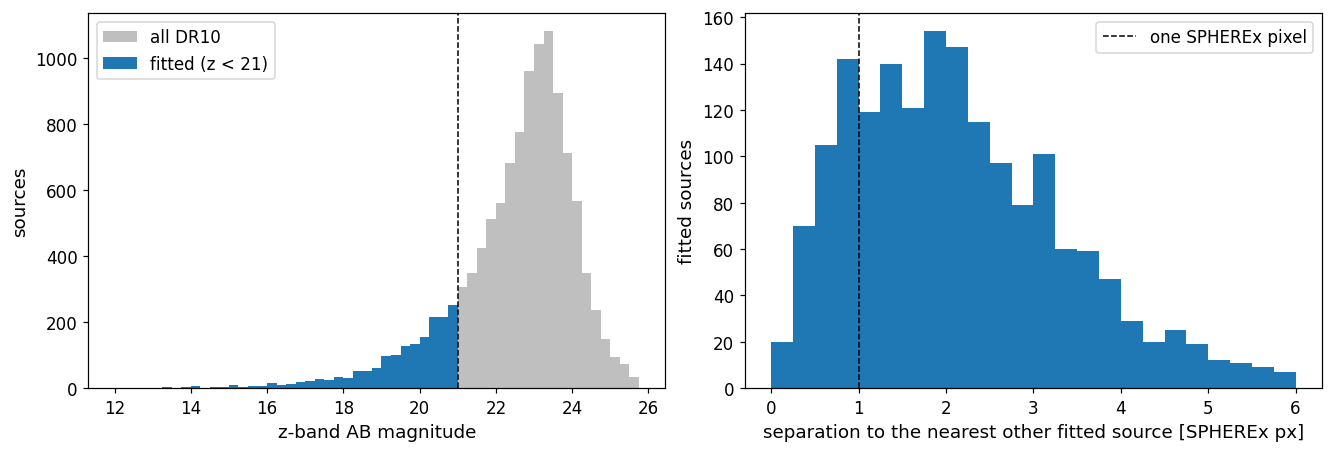

In [4]:
if not CATALOG.exists():
    fetch_ls_dr10(RA, DEC, cutout_pixels=BOX, name=NAME, out=CATALOG)

cat = Table.read(CATALOG)
cat["zmag"] = zmag_from_flux_z(cat["flux_z"])
is_gal = np.asarray(cat["shape_r"]) > 0
fitted = np.isfinite(cat["zmag"]) & (cat["zmag"] < 21)
print(f"{len(cat)} DR10 sources within {0.5 * np.sqrt(2) * BOX * PIX / 60:.1f}' "
      f"({is_gal.sum()} extended); {fitted.sum()} brighter than z = 21 "
      f"({(fitted & is_gal).sum()} extended) will be fitted by default")

# How crowded is it, at the depth that will be fitted?
fit = cat[fitted]
sc_fit = SkyCoord(fit["ra"], fit["dec"], unit="deg")
_, sep_nn, _ = sc_fit.match_to_catalog_sky(sc_fit, nthneighbor=2)
sep_nn = sep_nn.arcsec
print(f"of those, {np.sum(sep_nn < PIX)} have another fitted source within one "
      f"SPHEREx pixel and {np.sum(sep_nn < 2 * PIX)} within two")

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axs[0].hist(cat["zmag"][np.isfinite(cat["zmag"])], bins=np.arange(12, 26, 0.25),
            color="0.75", label="all DR10")
axs[0].hist(fit["zmag"], bins=np.arange(12, 26, 0.25), color="C0", label="fitted (z < 21)")
axs[0].axvline(21, color="k", ls="--", lw=1)
axs[0].set_xlabel("z-band AB magnitude")
axs[0].set_ylabel("sources")
axs[0].legend(loc="upper left")
axs[1].hist(sep_nn / PIX, bins=np.arange(0, 6.01, 0.25), color="C0")
axs[1].axvline(1, color="k", ls="--", lw=1, label="one SPHEREx pixel")
axs[1].set_xlabel("separation to the nearest other fitted source [SPHEREx px]")
axs[1].set_ylabel("fitted sources")
axs[1].legend()
plt.show()

### The target and its neighbours

The BCG is the source nearest the field centre. Its Legacy Survey thumbnail
(0.262″ pixels, ~25× finer than SPHEREx) shows what the joint fit has to
separate: every marked entry is a catalog source that will be rendered through
the SPHEREx PSF at its own fixed position and shape. Galaxies are drawn as their
catalog half-light ellipses (`shape_r`, `shape_e1`, `shape_e2`), point sources
as crosses. Cyan is the BCG, white are neighbours that pass the depth cut and
are fitted alongside it, grey dotted are fainter entries the default
configuration leaves out.

BCG: ls_id=10995450559597381  type=SER  z-mag=16.00  shape_r=7.13"  sersic=3.10
11 catalog entries within two SPHEREx pixels (12.3"):
     4.5"  z=21.63  DEV   dropped by the z<21 cut
     5.3"  z=19.60  REX   fitted
     5.6"  z=20.28  REX   fitted
     6.2"  z=21.55  REX   dropped by the z<21 cut
     8.1"  z=20.36  REX   fitted
     8.3"  z=22.61  REX   dropped by the z<21 cut
     8.5"  z=21.35  REX   dropped by the z<21 cut
     8.5"  z=23.39  REX   dropped by the z<21 cut
     8.8"  z=22.14  REX   dropped by the z<21 cut
    10.3"  z=22.27  REX   dropped by the z<21 cut
    11.7"  z=19.38  SER   fitted


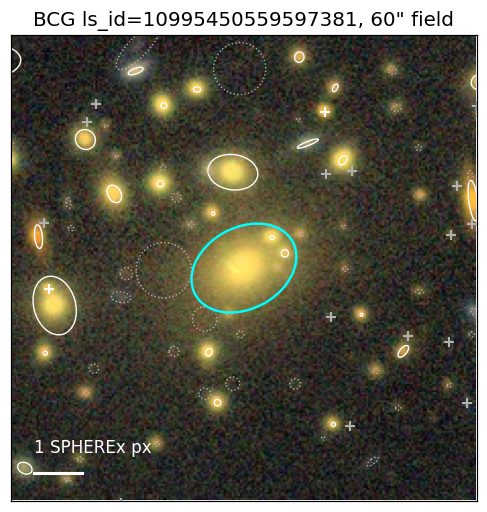

In [5]:
sc_all = SkyCoord(cat["ra"], cat["dec"], unit="deg")
i_bcg = int(np.argmin(sc_all.separation(SkyCoord(RA * u.deg, DEC * u.deg))))
bcg = cat[i_bcg]
BCG_ID = int(bcg["ls_id"])
print(f"BCG: ls_id={BCG_ID}  type={bcg['type']}  z-mag={bcg['zmag']:.2f}  "
      f"shape_r={bcg['shape_r']:.2f}\"  sersic={bcg['sersic']:.2f}")
sep_bcg = sc_all[i_bcg].separation(sc_all).arcsec
near = np.argsort(sep_bcg)[1:]
near = near[sep_bcg[near] < 2 * PIX]
print(f"{len(near)} catalog entries within two SPHEREx pixels ({2 * PIX:.1f}\"):")
for j in near:
    tag = "fitted" if fitted[j] else "dropped by the z<21 cut"
    print(f"   {sep_bcg[j]:5.1f}\"  z={cat['zmag'][j]:5.2f}  {cat['type'][j]:<4}  {tag}")


def ls_thumbnail(ra, dec, fov_arcsec=60.0, pixscale=0.262):
    """Legacy Survey DR10 colour image, north up / east left, or None offline."""
    size = int(round(fov_arcsec / pixscale))
    url = (f"https://www.legacysurvey.org/viewer/jpeg-cutout?ra={ra}&dec={dec}"
           f"&layer=ls-dr10&pixscale={pixscale}&size={size}")
    try:
        with urlopen(url, timeout=60) as resp:
            return plt.imread(BytesIO(resp.read()), format="jpeg"), pixscale
    except Exception as exc:  # noqa: BLE001 - offline is a legitimate state
        print("Legacy Survey thumbnail unavailable:", exc)
        return None, pixscale


def draw_source(ax, row, to_xy, arcsec_per_px, color, lw=0.9, ls="-"):
    """One catalog entry as the Legacy Survey model shape: a cross for a point
    source, otherwise the half-light ellipse (semi-major ``shape_r``, axis ratio
    from ``shape_e1``/``shape_e2``, position angle east of north). ``to_xy``
    maps (ra, dec) [deg] to pixel coordinates of the image being drawn on; the
    position angle is carried into that frame by probing ``to_xy`` 1" along the
    major axis, so the same code serves the thumbnail and the SPHEREx cutout.
    """
    ra, dec = float(row["ra"]), float(row["dec"])
    x0, y0 = to_xy(ra, dec)
    r = float(row["shape_r"])
    if r <= 0 or str(row["type"]) in ("PSF", "DUP"):
        ax.plot(x0, y0, "+", color=color, ms=7, mew=lw + 0.4)
        return
    e1, e2 = float(row["shape_e1"]), float(row["shape_e2"])
    e = np.hypot(e1, e2)
    ba = (1 - e) / (1 + e)
    # Legacy Survey / tractor EllipseE: theta = 0.5 atan2(e2, e1) is the major
    # axis position angle east of north, i.e. the axis points along
    # (sin theta, cos theta) in (East, North). Probe to_xy 1" along it.
    theta = 0.5 * np.arctan2(e2, e1)
    step = 1.0 / 3600
    x1, y1 = to_xy(ra + step * np.sin(theta) / np.cos(np.radians(dec)),
                   dec + step * np.cos(theta))
    ang = np.degrees(np.arctan2(y1 - y0, x1 - x0))
    a = r / arcsec_per_px
    ax.add_patch(Ellipse((x0, y0), 2 * a, 2 * a * ba, angle=ang, fill=False,
                         ec=color, lw=lw, ls=ls))


def draw_neighbourhood(ax, ra, dec, fov_arcsec=60.0, partners=()):
    """LS thumbnail with the catalog entries around (ra, dec) drawn as shapes.

    ``partners`` = [(ra, dec, color), ...] draws those entries in their own colour.
    """
    img, pixscale = ls_thumbnail(ra, dec, fov_arcsec)
    if img is None:
        ax.text(0.5, 0.5, "thumbnail unavailable", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        return
    n = img.shape[0]
    ax.imshow(img, origin="upper")

    def to_xy(ra_s, dec_s):                     # tangent plane: east left, north up
        dx = (ra_s - ra) * np.cos(np.radians(dec)) * 3600 / pixscale
        dy = (dec_s - dec) * 3600 / pixscale
        return n / 2 - dx, n / 2 - dy

    d = sc_all.separation(SkyCoord(ra * u.deg, dec * u.deg)).arcsec
    for j in np.where(d < 0.75 * fov_arcsec)[0]:
        target = abs(cat["ra"][j] - ra) < 1e-6 and abs(cat["dec"][j] - dec) < 1e-6
        color = "cyan" if target else ("white" if fitted[j] else "0.7")
        for pra, pdec, pcol in partners:
            if abs(cat["ra"][j] - pra) < 1e-6 and abs(cat["dec"][j] - pdec) < 1e-6:
                color, target = pcol, True
        draw_source(ax, cat[j], to_xy, pixscale, color, lw=1.6 if target else 0.9,
                    ls="-" if fitted[j] else ":")
    bar = PIX / pixscale
    ax.plot([0.05 * n, 0.05 * n + bar], [0.94 * n, 0.94 * n], color="w", lw=2)
    ax.text(0.05 * n, 0.905 * n, "1 SPHEREx px", color="w", ha="left", va="bottom", fontsize=11)
    ax.set_xlim(0, n); ax.set_ylim(n, 0)
    ax.set_xticks([]); ax.set_yticks([])


fig, ax = plt.subplots(figsize=(5.5, 5.5))
draw_neighbourhood(ax, float(bcg["ra"]), float(bcg["dec"]), fov_arcsec=60)
ax.set_title(f"BCG ls_id={BCG_ID}, 60\" field")
plt.show()

## 4. Configure: the configuration of record

`PhotometryConfig()` with no arguments **is** the recommended setup. It is the
configuration the SPHEREx deblending campaign carries, and every calibration
quoted in the docs was measured on it:

| setting | default | what it buys you |
|---|---|---|
| `solver="eigfloor"` | eigenvalue floor $10^{-2}$ | sign-free fluxes with calibrated errors (pull NMAD ≈ 0.95–0.99); no faint-end bias |
| `fit_zmag_max=21` | fit only $m_z < 21$ | at full DR10 depth there are ~22 sources per PSF core and the solve is under-determined; sources fainter than 21 are below the single-visit noise, so the cut removes ~85 % of the catalog and *improves* the photometry of the rest (section 7 measures it on this field) |
| `bkg_model="cwave+photutils"` | airglow-aware background | the He I 1.083 µm line is a stripe in detector coordinates that a 2-D background cannot see; fitting the wavelength profile first removes it |
| `tile_size=15`, `tile_halo=3` | 15 px cores, 3 px halo, one free constant per tile | the geometry the estimator was calibrated on; the tile is part of the estimator |
| `psf_zone_interp=True`, `psf_core_shift=True` | zone-blended PSF, re-registered on its measured core | turning the core shift off moves per-visit fluxes of blended sources by up to 13–15 % |
| `precision="fp32"`, `pad_bucket=32`, `prefetch="thread"` | | the error calibration was established at fp32; the rest is throughput only |

Two knobs are worth setting explicitly and change nothing in the result:
`gpu_preallocate=False, gpu_mem_fraction=0.45` keep the run under half the card
on a shared GPU. Add `device="cpu"` if you have none.

When to deviate: fit the **full catalog** only with `eigfloor_prior`
(`fit_zmag_max=None, protect_zmag_max=21`), which ridges the faint nuisances
toward their Legacy Survey SED prediction while the $m_z<21$ sources stay exactly
`eigfloor`; use `lasso` for a handful of bright targets where you want the
smallest scatter and can live with under-covering errors. See *Choosing a
solver* in the docs.

In [6]:
cfg = PhotometryConfig(gpu_preallocate=False, gpu_mem_fraction=0.45)
cfg.to_yaml(OUT / "run.yaml")      # the run is reproducible from this file
print(yaml.safe_dump(cfg.to_dict(), sort_keys=False))

solver: eigfloor
eig_floor: 0.01
lasso_alpha: auto
lasso_n_iter: 1000
protect_zmag_max: 20.0
prior_sigma_frac: 0.15
prior_sigma_min_ujy: 5.0
fit_zmag_max: 21.0
tile_size: 15
tile_halo: 3
pad_bucket: 32
tile_chunk: 0
max_ps_cap: null
max_gal_cap: null
max_mog_k_cap: null
cap_auto_margin: 1.1
strict: false
cpu_tiling: true
cpu_tile_background: true
bkg_model: cwave+photutils
bkg_box_size: 10
bkg_filter_size: 3
bkg_cwave_nbins: 48
bkg_cwave_min_per_bin: 20
psf_sampling: 0.2
psf_zone_interp: true
psf_core_shift: true
fixed_max_factor: 5.0
backend: jax
device: auto
precision: fp32
prefetch: thread
gpu_mem_fraction: 0.45
gpu_preallocate: false



## 5. Run forced photometry

One call. `target=(RA, DEC)` names the source that is always kept and labelled
the main source; without it the catalog centroid is used. The output parquet
carries the full configuration, the package version and a completeness flag in
its metadata, and `resume=True` with the same `output` continues an interrupted
run.

The command-line equivalent of this cell is

```bash
tractorjax-spherex run --cutouts-dir a2537_out/cutouts --catalog a2537_out/ls_dr10.parquet \
    --ra 347.09262 --dec -2.19217 --gpu-mem-fraction 0.45 --output a2537_out/phot.parquet
```

In [7]:
t0 = time.time()
# progress=False only keeps the stored notebook readable; interactively, leave
# the default progress bar on.
phot = run_photometry(CUTOUTS, CATALOG, cfg, target=(RA, DEC), output=PHOT, progress=False)
dt = time.time() - t0
n_src = len(np.unique(phot["id"]))
n_cut = len(np.unique(phot["cutout_index"]))
print(f"\n{dt / 60:.1f} min: {len(phot)} (source, visit) measurements for {n_src} sources "
      f"on {n_cut} cutouts; complete = {phot.meta['tractorjax_spherex.complete']}")
snr = phot["flux"] / phot["flux_err"]
print(f"per-visit S/N > 5 in {np.mean(snr > 5) * 100:.1f} % of the measurements; "
      f"{np.sum(np.isfinite(phot['central_wavelength']))} of them carry a wavelength")
phot[:5]

INFO tractorjax_spherex.pipeline: Processing 370 cutouts (backend=jax, solver=eigfloor)


INFO tractorjax_spherex.pipeline: Catalog: 11712 sources, 1730 fitted (fit_zmag_max=21.0); main source id=10995450559597381 at ra=347.09262 dec=-2.19217


INFO tractorjax_spherex.pipeline: Photometered 397026 rows across 370 cutouts



1.4 min: 397026 (source, visit) measurements for 1219 sources on 370 cutouts; complete = True
per-visit S/N > 5 in 12.8 % of the measurements; 397026 of them carry a wavelength


cutout_index,obs_id,detector,id,ra,dec,central_wavelength,bandwidth,flux,flux_err
int64,str32,int32,int64,float64,float64,float64,float64,float64,float64
1,2025W22_2B_0161_1,1,10995450559595082,347.01861572265625,-2.356548547744751,0.7681667039542974,0.01884764682668575,0.1104031428694725,0.09627646350260863
1,2025W22_2B_0161_1,1,10995450559594826,347.0098571777344,-2.3350601196289062,0.7662922817520298,0.018478402141233842,-0.17211851477622986,0.18934471922212587
1,2025W22_2B_0161_1,1,10995450559594911,347.0126037597656,-2.3360791206359863,0.7665041336263057,0.018136660969897633,0.07946634292602539,0.044117765341197254
1,2025W22_2B_0161_1,1,10995450559594927,347.0133056640625,-2.3346431255340576,0.7663187772348001,0.018164082898553122,0.08499655872583389,0.046248025348593395
1,2025W22_2B_0161_1,1,10995450559594853,347.0108642578125,-2.3302555084228516,0.7657293223006891,0.01835008062379877,4.983877658843994,1.4989814479053938


## 6. Inspect one fit

`plot_fit` re-renders every fitted source of one cutout at its measured flux,
through the same oversampled PSF the solver used, and shows the
background-subtracted **data**, the **model**, and **chi** = (data − model)/σ.
A good fit leaves chi as structureless noise. A blob centred on a source means
its flux, shape or position is wrong; coherent large-scale structure points at
the background model; a bright compact chi residual with *no* catalog entry on
it is a source missing from the reference catalog.

The full 150 px frame is shown first, then a 40 px window around the BCG with the
fitted sources drawn as their catalog shapes (half-light ellipses for galaxies,
crosses for point sources, cyan for the BCG), in SPHEREx pixels this time. This
is the visit in which the BCG was measured at its highest S/N.

cutout 352: obs_id=2026W25_2A_0179_2 D3  lambda=2.302 um  BCG flux=4.055 +- 0.129 mJy


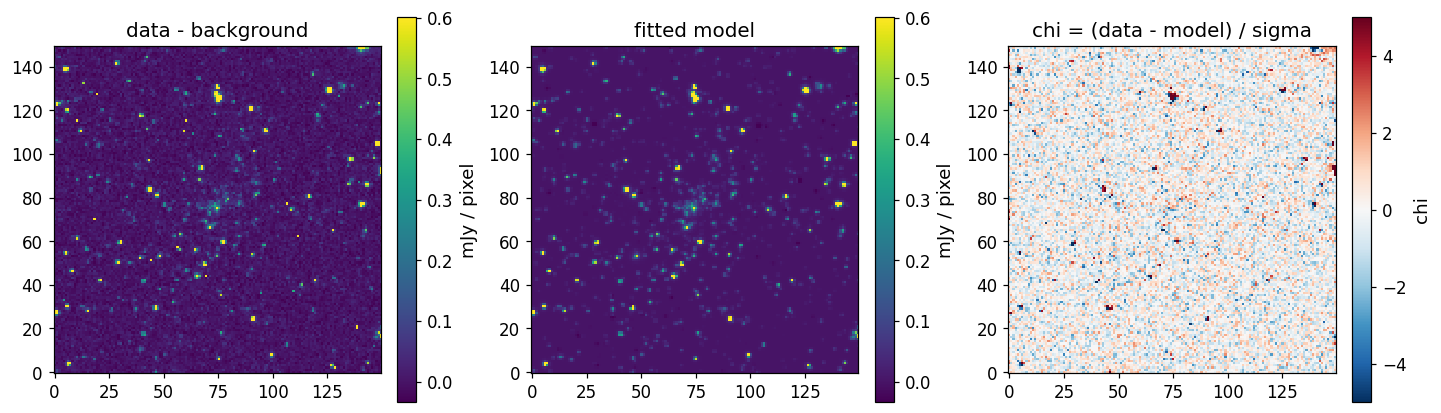

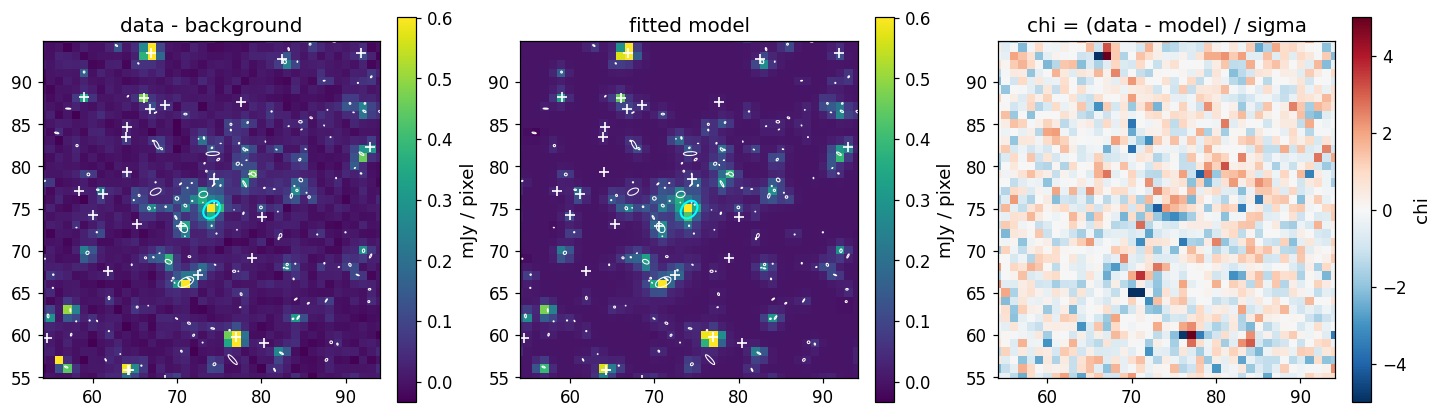

In [8]:
from tractorjax_spherex.diagnostics import plot_fit
from tractorjax_spherex.io.cutouts import discover_cutouts, read_cutout

pairs = dict(discover_cutouts(CUTOUTS))
rows_bcg = phot[phot["id"] == BCG_ID]
best = rows_bcg[np.argmax(rows_bcg["flux"] / rows_bcg["flux_err"])]
ci = int(best["cutout_index"])
cutout = read_cutout(pairs[ci])
print(f"cutout {ci}: obs_id={best['obs_id']} D{best['detector']}  "
      f"lambda={best['central_wavelength']:.3f} um  BCG flux={best['flux']:.3f} +- {best['flux_err']:.3f} mJy")

fig = plot_fit(cutout, cat[fitted], phot, cutout_index=ci, config=cfg, mark_sources=False)
fig.set_size_inches(13, 4.2)
plt.show()

fig = plot_fit(cutout, cat[fitted], phot, cutout_index=ci, config=cfg, mark_sources=False)
fig.set_size_inches(13, 4.2)


def to_xy_cutout(ra_s, dec_s):
    x, y = cutout.wcs.world_to_pixel(SkyCoord(ra_s * u.deg, dec_s * u.deg))
    return float(x), float(y)


x0, y0 = to_xy_cutout(float(bcg["ra"]), float(bcg["dec"]))
xs, ys = cutout.wcs.world_to_pixel(SkyCoord(fit["ra"], fit["dec"], unit="deg"))
in_window = (np.abs(xs - x0) < 21) & (np.abs(ys - y0) < 21)
for ax in fig.axes[:2]:               # data and model panels (colorbars follow the images)
    for j in np.where(in_window)[0]:
        is_bcg = int(fit["ls_id"][j]) == BCG_ID
        draw_source(ax, fit[j], to_xy_cutout, PIX, "cyan" if is_bcg else "white",
                    lw=1.4 if is_bcg else 0.7)
for ax in fig.axes[:3]:
    ax.set_xlim(x0 - 20, x0 + 20)
    ax.set_ylim(y0 - 20, y0 + 20)
plt.show()

## 7. Spectra

`build_spectra` groups the per-visit rows by source and sorts them by wavelength
(the within-detector wavelength reversal is handled for you). `bin_to_channels`
then combines the repeat visits with inverse-variance weights on the **102
SPHEREx spectral channels**: 17 channels of constant resolving power per
detector band, each visit assigned by its detector and wavelength
(`spherex_channels()` lists the definition). The channel points carry the
combined 1σ error bar; the faint points behind them are the individual visits.
The Legacy Survey and unWISE broadband fluxes from the catalog are drawn as
diamonds: they are an independent anchor measured through different apertures
at different epochs, so they should bracket the SPHEREx spectrum rather than
match it point for point.

1219 sources have at least one wavelength-labelled measurement


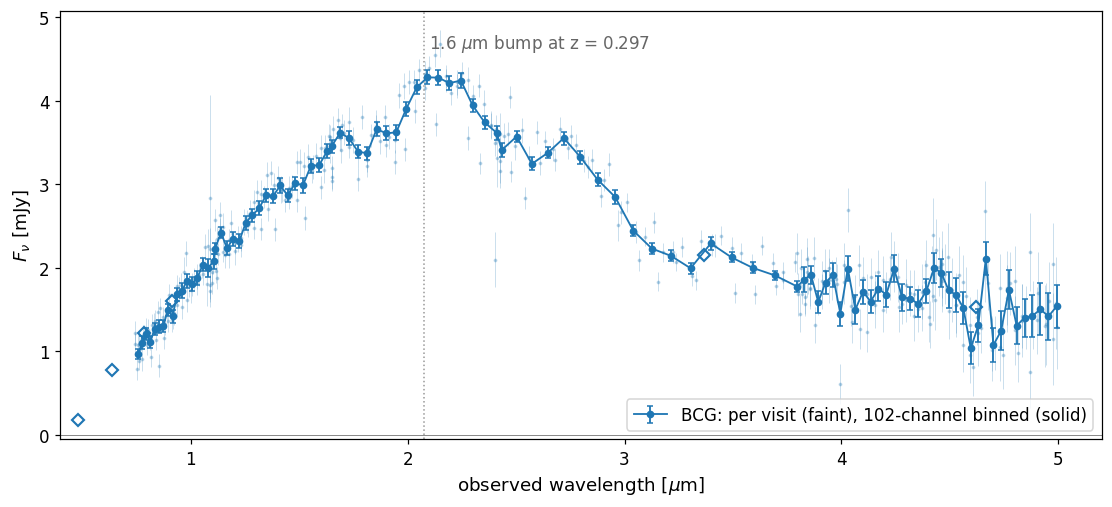

BCG: 342 visits in 102 of the 102 channels (2-6 visits per channel), median per-visit S/N 13.4, median channel S/N 25.5; flux 2.08 mJy (median); W1 anchor 2.15 mJy


channel,detector,central_wavelength,lambda_min,lambda_max,lambda_mean,flux,flux_err,n
int64,int64,float64,float64,float64,float64,float64,float64,int64
1,1,0.758950982259511,0.75,0.7679019645190219,0.7592856904913713,0.9702914559479586,0.05746416855394726,5
2,1,0.7770666003342932,0.7679019645190219,0.7862312361495644,0.7798084069260806,1.1015370136766496,0.07616493814543791,3
3,1,0.7956146252784286,0.7862312361495644,0.8049980144072928,0.7978141713909386,1.2053810710566168,0.07216569990612097,3
4,1,0.8146053783351611,0.8049980144072928,0.8242127422630294,0.816427664222765,1.1111440756271345,0.07374132861060902,3
5,1,0.8340494271084418,0.8242127422630294,0.8438861119538542,0.8363562748208148,1.2700816051715282,0.0737318806138413,3


In [9]:
spectra = build_spectra(phot)
print(f"{len(spectra)} sources have at least one wavelength-labelled measurement")

# Legacy Survey / unWISE broadband anchors: nanomaggies -> mJy at the band centres.
BANDS = {"g": 0.480, "r": 0.638, "i": 0.783, "z": 0.916, "w1": 3.368, "w2": 4.618}
NMGY_TO_MJY = 3.631e-3


def anchors(row):
    lam = np.array(list(BANDS.values()))
    f = np.array([row[f"dered_flux_{b}"] for b in BANDS]) * NMGY_TO_MJY
    return lam, f


def plot_source(ax, sid, row, color="C0", label=None):
    spec = spectra[sid]
    binned = bin_to_channels(spec)
    ax.errorbar(spec["central_wavelength"], spec["flux"], yerr=spec["flux_err"],
                fmt=".", ms=3, color=color, alpha=0.25, lw=0.6)
    ax.errorbar(binned["central_wavelength"], binned["flux"], yerr=binned["flux_err"],
                fmt="o-", ms=4, color=color, lw=1.2, elinewidth=1.2, capsize=2,
                label=label or f"ls_id={sid}")
    lam, f = anchors(row)
    ax.plot(lam, f, "D", ms=6, mfc="none", mec=color, mew=1.4)
    ax.axhline(0, color="0.5", lw=0.6)
    ax.set_xlim(0.4, 5.2)
    ax.set_xlabel("observed wavelength [$\\mu$m]")
    ax.set_ylabel("$F_\\nu$ [mJy]")
    return spec, binned


fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
spec, binned = plot_source(ax, BCG_ID, bcg, label="BCG: per visit (faint), 102-channel binned (solid)")
ax.axvline(1.6 * (1 + Z_CL), color="0.6", ls=":", lw=1)
ax.text(1.6 * (1 + Z_CL), ax.get_ylim()[1] * 0.95, " 1.6 $\\mu$m bump at z = %.3f" % Z_CL,
        va="top", fontsize=11, color="0.4")
ax.legend(loc="lower right")
plt.show()

snr = spec["flux"] / spec["flux_err"]
print(f"BCG: {len(spec)} visits in {len(binned)} of the 102 channels "
      f"({binned['n'].min()}-{binned['n'].max()} visits per channel), median per-visit S/N "
      f"{np.median(snr):.1f}, median channel S/N {np.median(binned['flux'] / binned['flux_err']):.1f}; "
      f"flux {np.median(spec['flux']):.2f} mJy (median); W1 anchor {bcg['dered_flux_w1'] * NMGY_TO_MJY:.2f} mJy")
binned[:5]

### A blended pair

Now the case the question is really about: a bright galaxy with another catalog
source inside one SPHEREx pixel. The selection below is generic (brightest
extended $m_z<19$ source whose nearest fitted neighbour is closer than one pixel,
with both partners measured at a useful S/N), so it picks a comparable pair in
any field. The two spectra come out of the same joint solve; each visit's error
bar already includes the covariance with the partner.

pair separated by 4.06" (0.66 px):
   ls_id=10995452069547992  type=SER   z=16.99  shape_r=1.93"  median S/N 7.7
   ls_id=10995452069548021  type=PSF   z=17.78  shape_r=0.00"  median S/N 5.5


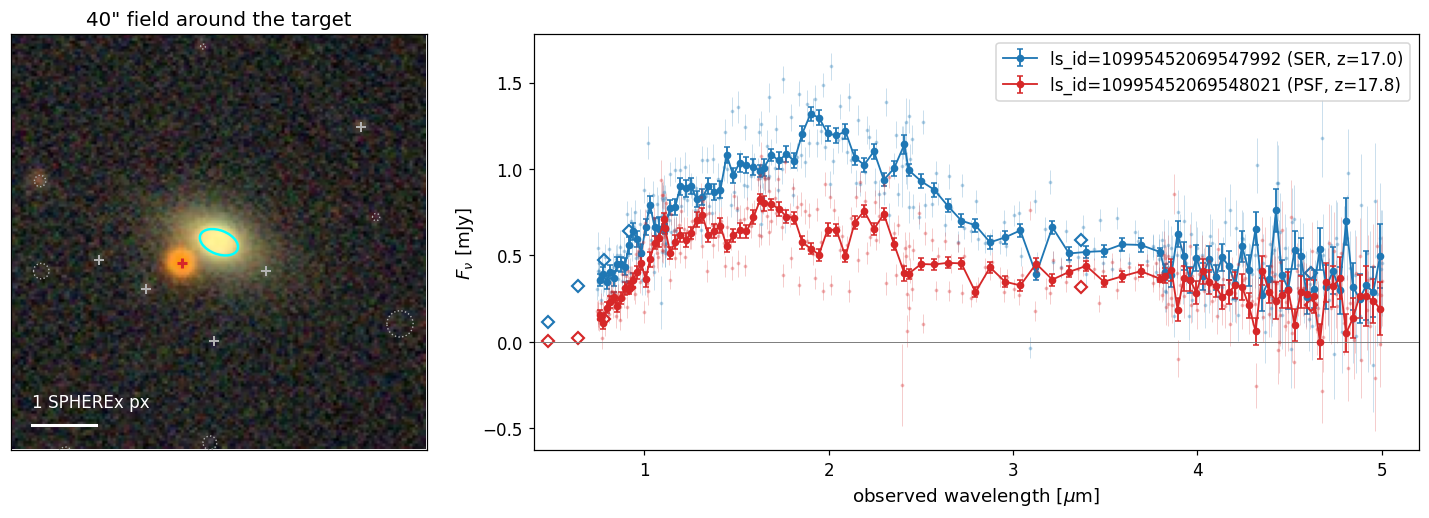

In [10]:
idx_nn, sep_nn_q, _ = sc_fit.match_to_catalog_sky(sc_fit, nthneighbor=2)


def median_snr(sid):
    s = spectra.get(int(sid))
    return float(np.median(s["flux"] / s["flux_err"])) if s is not None else 0.0


pair = None
for a in np.argsort(fit["zmag"]):
    b = int(idx_nn[a])
    if (fit["zmag"][a] < 19 and fit["shape_r"][a] > 0 and sep_nn_q[a].arcsec < PIX
            and median_snr(fit["ls_id"][a]) > 5 and median_snr(fit["ls_id"][b]) > 3):
        pair = (a, b)
        break
assert pair is not None, "no blended bright pair found; relax the S/N or magnitude limits"
a, b = pair
ra_a, dec_a = float(fit["ra"][a]), float(fit["dec"][a])
print(f"pair separated by {sep_nn_q[a].arcsec:.2f}\" ({sep_nn_q[a].arcsec / PIX:.2f} px):")
for k in (a, b):
    print(f"   ls_id={int(fit['ls_id'][k])}  type={fit['type'][k]:<4}  z={fit['zmag'][k]:.2f}  "
          f"shape_r={fit['shape_r'][k]:.2f}\"  median S/N {median_snr(fit['ls_id'][k]):.1f}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 2]})
draw_neighbourhood(ax0, ra_a, dec_a, fov_arcsec=40,
                   partners=[(float(fit["ra"][b]), float(fit["dec"][b]), "C3")])
ax0.set_title("40\" field around the target")
for k, color in ((a, "C0"), (b, "C3")):
    plot_source(ax1, int(fit["ls_id"][k]), fit[k], color=color,
                label=f"ls_id={int(fit['ls_id'][k])} ({fit['type'][k]}, z={fit['zmag'][k]:.1f})")
ax1.legend(loc="upper right")
plt.show()

## 8. Why the depth cut is the default

The one change that most often makes a first run worse is fitting the **full**
catalog. Here the same solver runs again with `fit_zmag_max=None`, so every DR10
source in the box (about seven times as many) gets a free flux. The safe
full-depth batching (`pad_bucket=0` with `"auto"` caps) is used so no cutout is
dropped; `tile_chunk` bounds the GPU memory of the larger solve.

The comparison is on the sources both runs fit. For each source with median
S/N > 5 in the default run, the robust scatter of its per-visit fluxes about its
own channel-binned spectrum is measured in both runs, and the ratio full-catalog /
default is reported; so is the share of their measurements that reach S/N > 5.
The several times more measurements the full fit produces belong to the added
faint sources, which are below the single-visit noise.

INFO tractorjax_spherex.pipeline: Processing 370 cutouts (backend=jax, solver=eigfloor)


INFO tractorjax_spherex.pipeline: Catalog: 11712 sources, 11712 fitted (fit_zmag_max=None); main source id=10995450559597381 at ra=347.09262 dec=-2.19217


INFO tractorjax_spherex.pipeline: Occupancy scan over 370 cutouts: densest tile holds 77 point sources / 257 galaxies


INFO tractorjax_spherex.pipeline: Photometered 2575227 rows across 370 cutouts



1.3 min: 2575227 measurements for 7929 sources


143 sources with median S/N > 5 in the default run:
   per-visit scatter, full catalog / default: median 1.24, 16-84 % range 1.01-2.03; wider in 89 % of them
   share of their measurements at S/N > 5: default 12.8 %, full catalog 9.2 %
   the full fit adds 2178201 measurements of 6710 sources fainter than z = 21


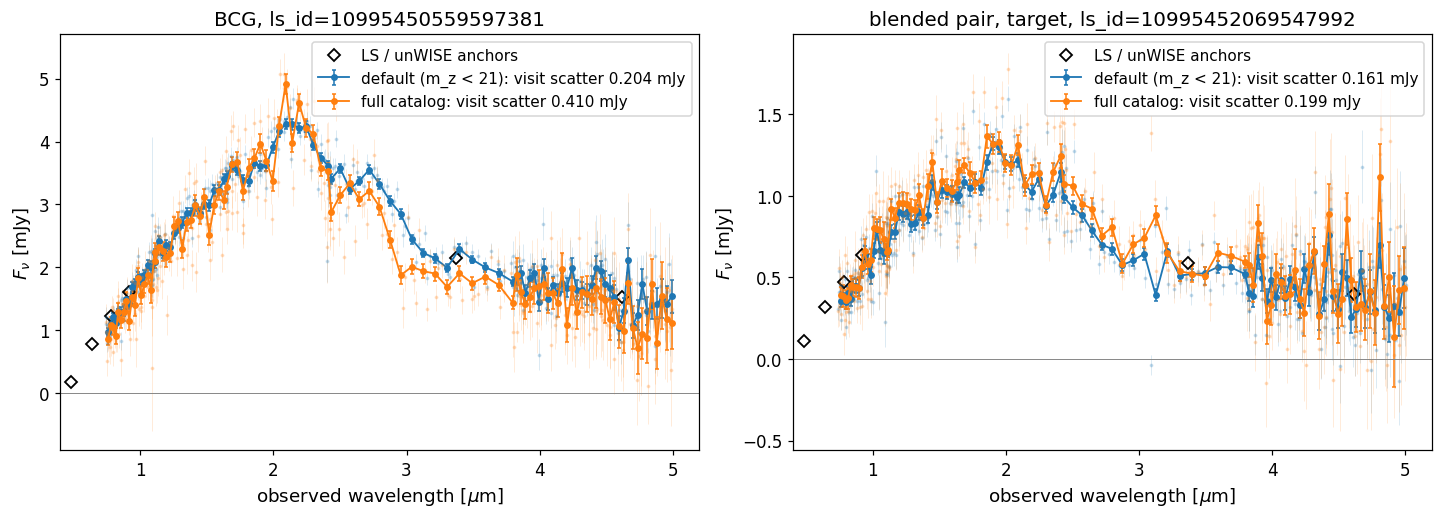

In [11]:
cfg_full = PhotometryConfig(gpu_preallocate=False, gpu_mem_fraction=0.45,
                            fit_zmag_max=None, pad_bucket=0,
                            max_ps_cap="auto", max_gal_cap="auto", tile_chunk=32)
t0 = time.time()
phot_full = run_photometry(CUTOUTS, CATALOG, cfg_full, target=(RA, DEC),
                           output=OUT / "phot_fulldepth.parquet", progress=False)
print(f"\n{(time.time() - t0) / 60:.1f} min: {len(phot_full)} measurements for "
      f"{len(np.unique(phot_full['id']))} sources")
spectra_full = build_spectra(phot_full)


def visit_scatter(spec):
    """Robust (1.4826 MAD) scatter of per-visit fluxes about the channel-binned spectrum."""
    binned = bin_to_channels(spec)
    model = np.interp(spec["central_wavelength"], binned["central_wavelength"], binned["flux"])
    r = np.asarray(spec["flux"] - model)
    return 1.4826 * np.median(np.abs(r - np.median(r)))


ratios, snr_full_of_bright = [], []
for sid, spec in spectra.items():
    if np.median(spec["flux"] / spec["flux_err"]) < 5 or sid not in spectra_full:
        continue
    sf = spectra_full[sid]
    ratios.append(visit_scatter(sf) / visit_scatter(spec))
    snr_full_of_bright.append(np.median(sf["flux"] / sf["flux_err"]))
ratios = np.array(ratios)
print(f"{len(ratios)} sources with median S/N > 5 in the default run:")
print(f"   per-visit scatter, full catalog / default: median {np.median(ratios):.2f}, "
      f"16-84 % range {np.percentile(ratios, 16):.2f}-{np.percentile(ratios, 84):.2f}; "
      f"wider in {np.mean(ratios > 1) * 100:.0f} % of them")
common = np.isin(phot_full["id"], np.unique(phot["id"]))
print(f"   share of their measurements at S/N > 5: default "
      f"{np.mean(phot['flux'] / phot['flux_err'] > 5) * 100:.1f} %, full catalog "
      f"{np.mean(phot_full['flux'][common] / phot_full['flux_err'][common] > 5) * 100:.1f} %")
print(f"   the full fit adds {len(phot_full) - common.sum()} measurements of "
      f"{len(np.unique(phot_full['id'])) - len(np.unique(phot['id']))} sources fainter than z = 21")

fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for ax, (sid, row, ttl) in zip(axs, ((BCG_ID, bcg, "BCG"),
                                     (int(fit["ls_id"][a]), fit[a], "blended pair, target"))):
    for src, color, label in ((spectra, "C0", "default (m_z < 21)"),
                              (spectra_full, "C1", "full catalog")):
        s = src[sid]
        bnd = bin_to_channels(s)
        ax.errorbar(s["central_wavelength"], s["flux"], yerr=s["flux_err"], fmt=".", ms=3,
                    color=color, alpha=0.2, lw=0.5)
        ax.errorbar(bnd["central_wavelength"], bnd["flux"], yerr=bnd["flux_err"], fmt="o-",
                    ms=3.5, color=color, lw=1.2, elinewidth=1.0, capsize=1.5,
                    label=f"{label}: visit scatter {visit_scatter(s):.3f} mJy")
    lam, f = anchors(row)
    ax.plot(lam, f, "D", ms=6, mfc="none", mec="k", mew=1.2, label="LS / unWISE anchors")
    ax.axhline(0, color="0.5", lw=0.6)
    ax.set_xlim(0.4, 5.2)
    ax.set_xlabel("observed wavelength [$\\mu$m]")
    ax.set_ylabel("$F_\\nu$ [mJy]")
    ax.set_title(f"{ttl}, ls_id={sid}")
    ax.legend(loc="upper right", fontsize=10)
plt.show()

The full-catalog fit gives the same sources a wider per-visit scatter and a
smaller share of significant measurements, for no gain: the added sources are
below the noise of a single visit and come back as noise around zero.
This is what an untuned `fit_zmag_max=None` run looks like, and why the cut is
the default. If you must fit everything, use `eigfloor_prior` with
`protect_zmag_max=21`, which constrains those faint nuisances with their
Legacy Survey SEDs instead of leaving them free.

## 9. Save, and adapt to your own field

Per-source spectra are plain Astropy tables; the ECSV below keeps `obs_id`,
`detector` and `cutout_index` for provenance, and the channel-binned version
is written alongside. The photometry parquet already carries the configuration
in its metadata.

To run this on another field, whatever its science (a cluster, a single target
and its neighbours, a survey patch), change five things and keep the rest:

1. **Centre and field radius** → `RA, DEC, FIELD_RADIUS_DEG`; the box follows
   from the rule in section 1. Cover every source you care about plus its
   neighbourhood; keep the box above ~50 px.
2. **The same `cutout_pixels`** for `fetch_ls_dr10` as for `retrieve`, so the
   catalog covers every cutout. Outside the Legacy Survey footprint, bring your
   own catalog with `id, ra, dec, flux_z` and the shape columns (see *Reference
   catalogs* in the docs); include the neighbours, not just your targets.
3. **`target`** = your main source, so it is kept and labelled whatever the cut.
4. **Check extended sources for catalog shredding** before trusting their
   spectra: several catalog entries sitting *inside* one galaxy means its light
   is being divided among artifacts. The docs' gallery shows a real A2537 case.
5. **Leave `PhotometryConfig()` alone** for the blind product. Switch to
   `eigfloor_prior` (`fit_zmag_max=None, protect_zmag_max=21`) only if you need
   fluxes for sources fainter than $m_z=21$, and to `lasso` for a few bright
   targets where the smallest scatter matters more than calibrated errors.

In [12]:
spec_dir = OUT / "spectra"
spec_dir.mkdir(exist_ok=True)
bright_ids = [int(s) for s in fit["ls_id"][fit["zmag"] < 19] if int(s) in spectra]
for sid in bright_ids:
    spectra[sid].write(spec_dir / f"spec_{sid}.ecsv", overwrite=True)
    bin_to_channels(spectra[sid]).write(spec_dir / f"spec_{sid}_channels.ecsv", overwrite=True)
print(f"wrote {len(bright_ids)} per-visit + channel-binned spectra of m_z < 19 sources to {spec_dir}/")
print("configuration recorded in the photometry file:",
      Table.read(PHOT).meta["tractorjax_spherex.config"][:80], "...")

wrote 295 per-visit + channel-binned spectra of m_z < 19 sources to a2537_out/spectra/
configuration recorded in the photometry file: {"backend": "jax", "bkg_box_size": 10, "bkg_cwave_min_per_bin": 20, "bkg_cwave_n ...
